In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('../data/raw/VNDA.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date']) # Loại bỏ dòng lỗi nếu có
df = df.sort_values('Date')
df = df.set_index('Date')

series_original = df['Adjusted Close'].copy()

print(f"Dữ liệu từ: {df.index.min()} đến {df.index.max()}")
print(f"Tổng số dòng: {len(df)}")

Dữ liệu từ: 2006-04-12 00:00:00 đến 2022-12-12 00:00:00
Tổng số dòng: 4197


2.4.2 phân tích khám phá chuỗi thời gian.<br>
a. vẽ time plot và xác định bằng mắt các thành phần: xu hướng, mùa vụ, nhiễu.

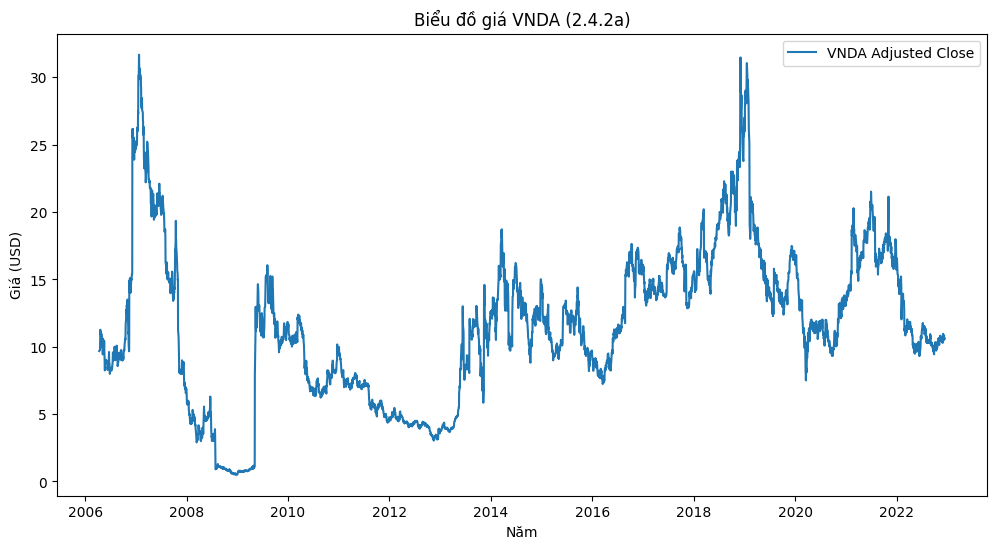

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(series_original, label='VNDA Adjusted Close')
plt.title('Biểu đồ giá VNDA (2.4.2a)')
plt.xlabel('Năm')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()

Đánh giá xu hướng(trend): giá cổ phiếu VNDA cao nhất vào khoảng năm 2007 và 2019, xuất hiện các đợt tăng giảm đột đột ngột.<br>
Đánh giá mùa vụ(seasonality): không có tính mùa vụ, các đỉnh không cách đều nhau theo từng chu kỳ.<br>
Đánh giá nhiễu(Noise): dữ liệu có độ nhiễu cao, dao động liên tục, là đặc trưng của dữ liệu tài chính vì có các dao động ngắn hạn và liên tục.<br>

b. Vẽ AFCF và PACF với lag tối đa cụ thể.<br>

In [6]:
n = len(df)
lag_max = int(min(10 * np.log10(n), n / 5))
print(f"Số lượng quan sát (n): {n}")
print(f"Số lag tối đa nên chọn: {lag_max}")

Số lượng quan sát (n): 4197
Số lag tối đa nên chọn: 36


Vẽ sơ đồ tương quan AFCF

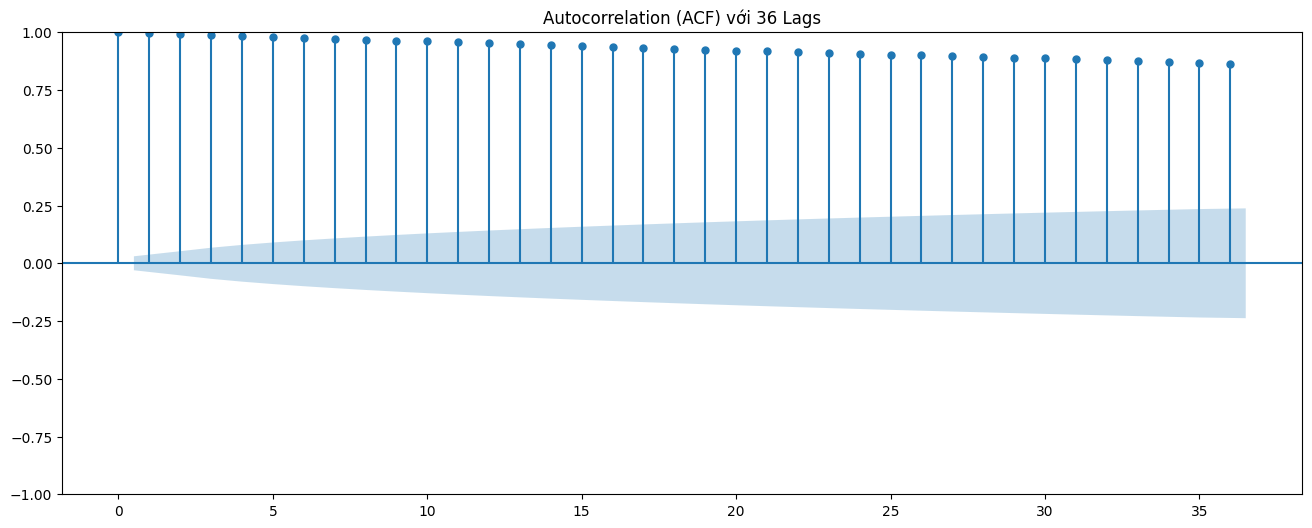

In [16]:
#Thiết lập số lag là 36
n_lags = 36
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Vẽ ACF
plot_acf(df['Adjusted Close'], lags=n_lags, ax=ax)
ax.set_title(f'Autocorrelation (ACF) với {n_lags} Lags')


plt.show()

-Sơ đồ tương quan có các cột hệ số tương quan giảm chậm từ lag 1 tới lag 36, ở lag 36 tỉ lệ tương quan vẫn ở mức cao.<br>
-Tất cả 36 lag đều nằm ngoài vùng tin cậy(vùng bóng màu xanh mờ). <br>
-Dữ liệu có tính tương quan mạnh.

Vẽ sơ đồ tương quan ACF

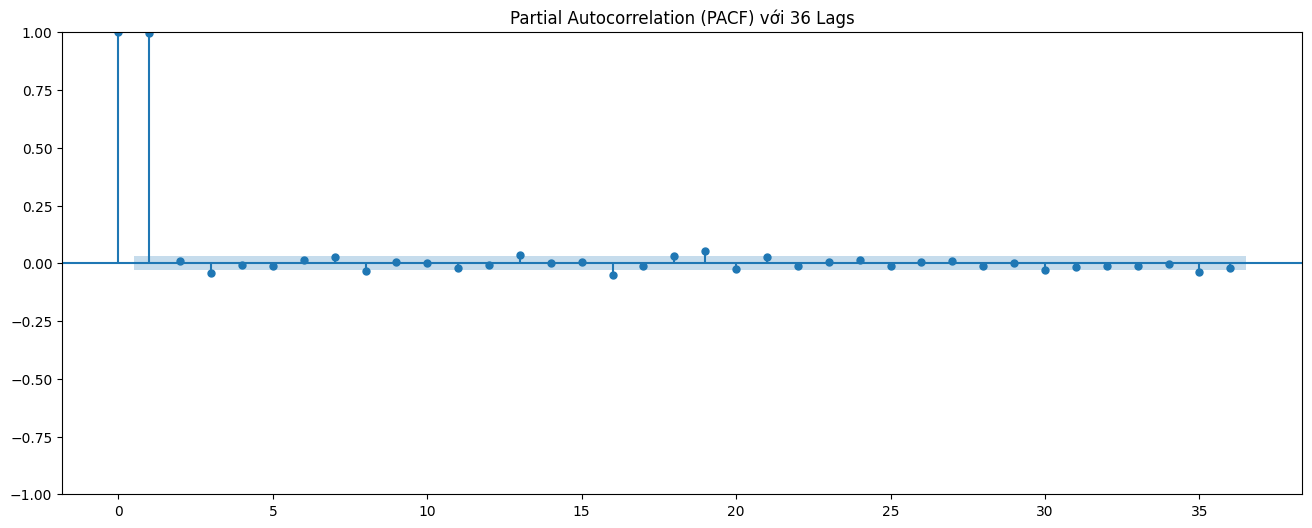

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
plot_pacf(df['Adjusted Close'], lags=n_lags, ax=ax)
ax.set_title(f'Partial Autocorrelation (PACF) với {n_lags} Lags')

plt.show()

-Giá trị lag 1 và lag 2 vượt cao khỏi vùng tin cậy, cho thấy sự tương quan mạnh với hai ngày trước đó.<br>
-Từ lag 3 các hệ số đa phần đi trong vùng tin cậy, có một vài cột vượt qua vùng tin cậy nhưng không đáng kể so với lag1 và lag 2.<br>


c.Tính rolling statistics: trung bình trượt và độ lệch chuẩn với cửa số trượt 7, 30 và 90
ngày (hoặc tương đương). Có thể trực quan hóa và nhận xét tính dừng sơ bộ.

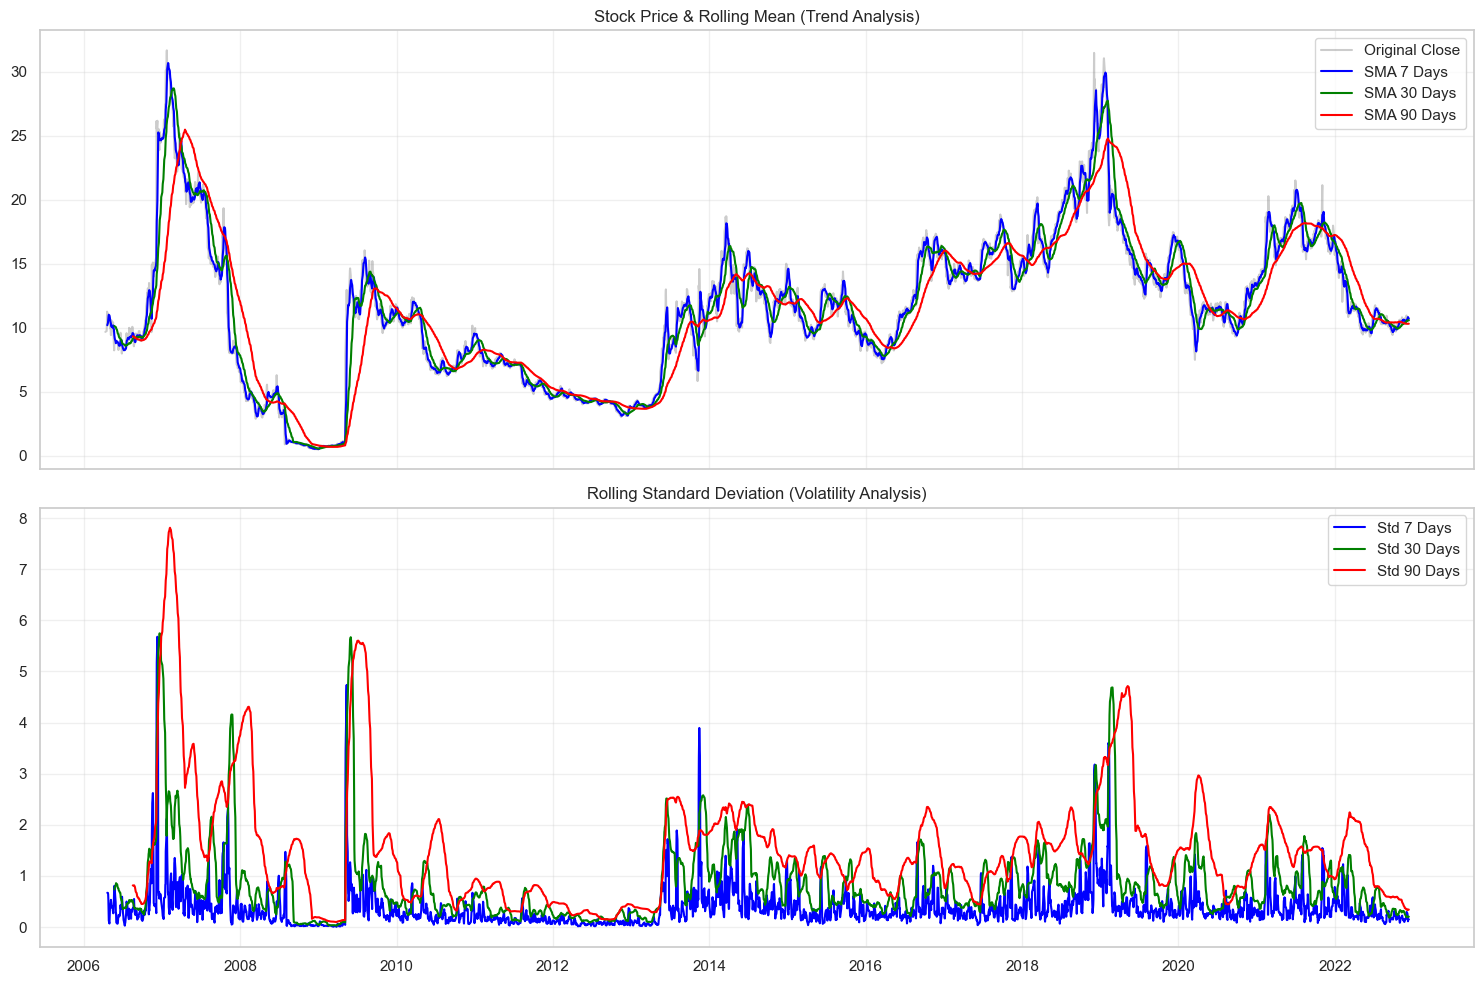

In [10]:

df = pd.read_csv('../data/raw/VNDA.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sắp xếp theo thời gian (quan trọng để tính rolling chính xác)
df = df.sort_values('Date')

# Đặt Date làm Index
df.set_index('Date', inplace=True)

# 3. Tính toán Rolling Statistics cho cột 'Close'
# Bạn có thể thay 'Close' bằng 'Adjusted Close' nếu muốn
windows = [7, 30, 90]
for w in windows:
    df[f'SMA_{w}'] = df['Close'].rolling(window=w).mean()
    df[f'Std_{w}'] = df['Close'].rolling(window=w).std()

# 4. Trực quan hóa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Đồ thị Trung bình trượt (SMA)
ax1.plot(df['Close'], label='Original Close', alpha=0.4, color='gray')
colors = {7: 'blue', 30: 'green', 90: 'red'}
for w in windows:
    ax1.plot(df[f'SMA_{w}'], label=f'SMA {w} Days', color=colors[w])
ax1.set_title('Stock Price & Rolling Mean (Trend Analysis)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Đồ thị Độ lệch chuẩn (Volatility)
for w in windows:
    ax2.plot(df[f'Std_{w}'], label=f'Std {w} Days', color=colors[w])
ax2.set_title('Rolling Standard Deviation (Volatility Analysis)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--Nhận xét về tính dừng sơ bộ.<br>
- đồ thị trung bình trượt (SMA) có dốc độ lớn với mọi cửa sổ trượt, cho thấy dữ liệu có tính trend, không dừng.<br>
- đồ thị độ lệch chuẩn thay đổi biên độ theo thời gian, phương sai không là hằng số, không dừng.<br>

2.4.3 các kỹ thuật tiền xử lý nâng cao.<br>


b. Kiểm định tính dừng.


---1. CHUỖI GỐC---
ADF p-value: 0.0653 -> Không dừng
KPSS p-value: 0.0100 -> Dừng

---2. BIẾN ĐỔI LOGARITHM---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6952\447316612.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(data, regression='c', nlags="auto")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6952\447316612.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(data, regression='c', nlags="auto")


ADF p-value: 0.1012 -> Không dừng
KPSS p-value: 0.0100 -> Dừng
Lambda Box-Cox: 0.7521

---3. BIẾN ĐỔI BOX-COX---
ADF p-value: 0.0739 -> Không dừng
KPSS p-value: 0.0100 -> Dừng

---4. SAI PHÂN BẬC 1 (LOG_DIFF)---
ADF p-value: 0.0000 -> Dừng
KPSS p-value: 0.1000 -> Không dừng

---5. SAI PHÂN BẬC 2 (LOG_DIFF)---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6952\447316612.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(data, regression='c', nlags="auto")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6952\447316612.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data, regression='c', nlags="auto")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6952\447316612.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data, regression='c', nlags="auto")


ADF p-value: 0.0000 -> Dừng
KPSS p-value: 0.1000 -> Không dừng


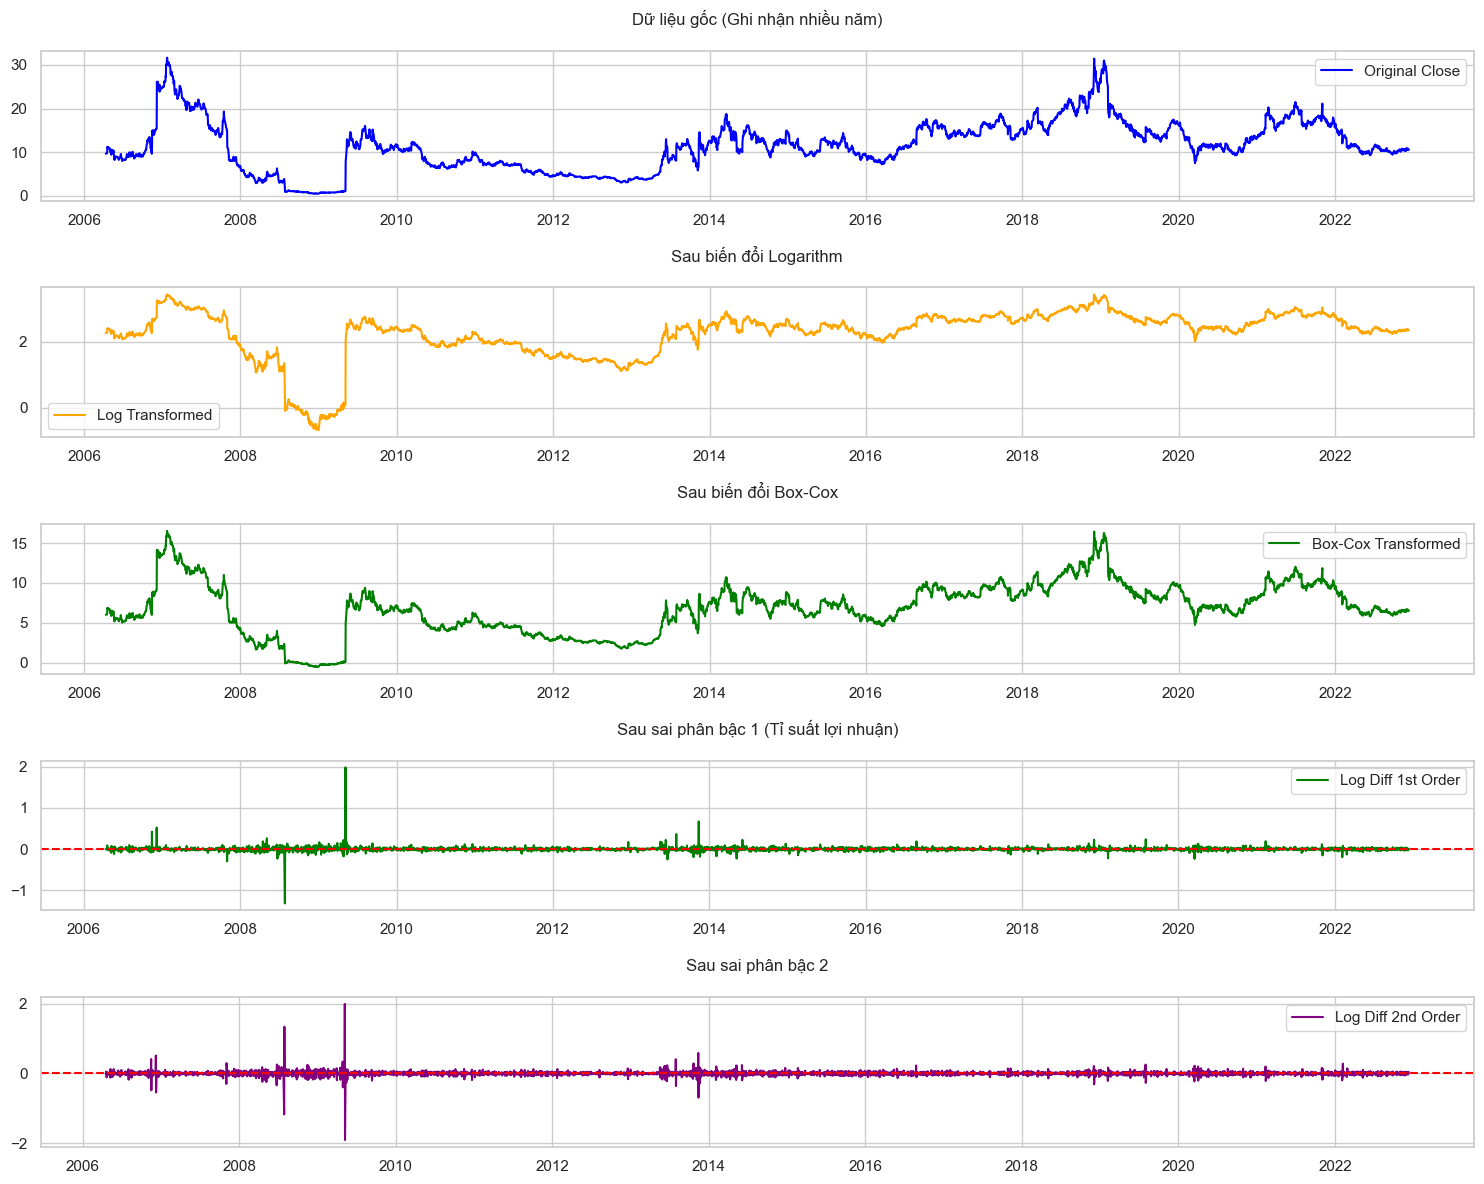

In [25]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller, kpss

#đọc dữ liệu 
df = pd.read_csv('../data/raw/VNDA.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').set_index('Date')

sns.set(style="whitegrid")
series = df['Close'].dropna()

#hàm kiểm định
def check_stationarity(data, label):
    print(f"\n---{label}---")
    #ADF
    adf_result = adfuller(data)
    print(f"ADF p-value: {adf_result[1]:.4f} -> {'Dừng' if adf_result[1] < 0.05 else 'Không dừng'}")

    #KPSS
    kpss_res = kpss(data, regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_res[1]:.4f} -> {'Dừng' if kpss_res[1] < 0.05 else 'Không dừng'}")

check_stationarity(series, "1. CHUỖI GỐC")

# Logarithm (Ổn định phương sai)
df['Log_Close'] = np.log(series)
check_stationarity(df['Log_Close'], "2. BIẾN ĐỔI LOGARITHM")

#  Box-Cox 
df['BoxCox_Close'], lmbda = boxcox(series)
print(f"Lambda Box-Cox: {lmbda:.4f}")
check_stationarity(df['BoxCox_Close'], "3. BIẾN ĐỔI BOX-COX")

# Phân sai bậc 1
df['Log_Diff1'] = df['Log_Close'].diff()
check_stationarity(df['Log_Diff1'].dropna(), "4. SAI PHÂN BẬC 1 (LOG_DIFF)")

#phân sai bậc 2
df['Log_Diff2'] = df['Log_Diff1'].diff()
check_stationarity(df['Log_Diff2'].dropna(), "5. SAI PHÂN BẬC 2 (LOG_DIFF)")

#Vẽ biểu đồ trực quan
plt.figure(figsize=(15, 12))

#đồ thị gốc
plt.subplot(5, 1, 1)
plt.plot(series, label='Original Close', color='blue')
plt.title('Dữ liệu gốc (Ghi nhận nhiều năm)\n')
plt.legend()

# Đồ thị sau Log
plt.subplot(5, 1, 2)
plt.plot(df['Log_Close'], label='Log Transformed', color='orange')
plt.title('Sau biến đổi Logarithm\n')
plt.legend()

# Đồ thị sau Box-Cox
plt.subplot(5, 1, 3)
plt.plot(df['BoxCox_Close'], label='Box-Cox Transformed', color='green')
plt.title('Sau biến đổi Box-Cox\n')
plt.legend()

# Đồ thị sau Sai phân bậc 1
plt.subplot(5, 1, 4)
plt.plot(df['Log_Diff1'], label='Log Diff 1st Order', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Sau sai phân bậc 1 (Tỉ suất lợi nhuận)\n')
plt.legend()

# Đồ thị sau Sai phân bậc 2
plt.subplot(5, 1, 5)
plt.plot(df['Log_Diff2'], label='Log Diff 2nd Order', color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Sau sai phân bậc 2\n')
plt.legend()
plt.tight_layout()
plt.show()

